# This note book helps training a generic llm (Qwen/Qwen2.5-0.5B-Instruct) to become smart using "Smart Calendar RL" with GRPO training

## dependency resolution

In [1]:
!pip install -U -q "trl" "transformers" "datasets" "accelerate" "peft" "bitsandbytes" "huggingface_hub" "torchao" "openenv-core[core]>=0.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [22]:
!git clone https://huggingface.co/spaces/kohantika/SmartCalendarRLDemo
%cd SmartCalendarRLDemo
!pip install -e .

Cloning into 'SmartCalendarRLDemo'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 170 (delta 88), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (170/170), 274.76 KiB | 1.88 MiB/s, done.
Resolving deltas: 100% (88/88), done.
/content/SmartCalendarRLDemo/SmartCalendarRLDemo
Obtaining file:///content/SmartCalendarRLDemo/SmartCalendarRLDemo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for openenv-smart_calendar_agent (pyproject.toml) ... done
  Created wheel for openenv-smart_calendar_agent: filename=openenv_smart_calendar_agent-0.1.0-0.editable-py3-none-any.whl size=3385 sha256=1aec9b1269e4f6f4351f6aeebd2ed224c7c48ebab73369c6f0b81e59cbc7f639
  Stored in directory: /tmp/pip-ephem-wh

## logging in to huggingface hub

In [23]:
from huggingface_hub import notebook_login
notebook_login()

## Collecting prompt examples in the form of Actions and see if we are getting right prompt or not

In [34]:
import json
from pathlib import Path
from datetime import datetime

from server.smart_calendar_agent_environment import CalendarEnv
from task_definitions import TaskDifficulty
from models import MyCalendarAction, ExpectedAction, PerformedAction, Slot
from inference import build_prompt, fallback_action, parse_time

def make_action(action_json):
    start_iso = parse_time(action_json["start_time"]).isoformat()
    end_iso = parse_time(action_json["end_time"]).isoformat()
    slot = Slot(start_time=start_iso, end_time=end_iso)
    event_id = str(action_json["event_id"])
    return MyCalendarAction(
        expected_action=ExpectedAction(
            command=action_json.get("command", "add_event"),
            slot=slot,
            event_id=event_id,
            day=action_json.get("day"),
        ),
        performed_action=PerformedAction(success=True, slot=slot, event_id=event_id),
    )

def collect_examples(repeats=30):
    rows = []
    for _ in range(repeats):
        for difficulty in [TaskDifficulty.EASY,TaskDifficulty.MEDIUM,TaskDifficulty.HARD, TaskDifficulty.SUPER_HARD]:
            env = CalendarEnv()
            env.reset(difficulty)
            for _step in range(12):
                state = env.state
                prompt = build_prompt(state)
                action_json = fallback_action(state.scheduled_meetings, state)
                obs = env.step(make_action(action_json))
                meta = obs.metadata or {}
                reward = float(meta.get("reward_objective_progress", 0.0))
                if meta.get("action_valid"):
                    rows.append({
                        "prompt": prompt,
                        "completion": json.dumps(action_json),
                        "reward": reward,
                        "difficulty": difficulty.value,
                    })
                if obs.done:
                    break
    return rows

rows = collect_examples(repeats=10)
Path("training_data").mkdir(exist_ok=True)
with open("training_data/smart_calendar_expert.json", "w") as f:
    for row in rows:
        f.write(json.dumps(row) + "\n")

len(rows), rows[0]

(220,
 {'prompt': 'You are a smart calendar scheduling agent.\nObjective: Schedule 1 meeting(s): kickoff\n\nProgress: 0 / 1 meetings scheduled\nAlready scheduled: []\nReady to schedule now (dependencies met): [\'kickoff\']\nDependency order: {\'kickoff\': []}\n\nFree slots (format: "day HH:MM-HH:MM UTC"): [\'monday 08:00-09:00 UTC\', \'monday 10:00-11:00 UTC\', \'monday 11:00-12:00 UTC\', \'monday 12:00-13:00 UTC\', \'monday 13:00-14:00 UTC\', \'monday 15:00-16:00 UTC\', \'monday 16:00-17:00 UTC\', \'monday 17:00-18:00 UTC\']\n\nCommands (return ONE as JSON):\n  add_event    — book a new meeting   (requires: event_id, day, start_time, end_time)\n  search_slot  — query free slots     (requires: day)\n  move_event   — reschedule a meeting (requires: event_id, day, start_time, end_time)\n  delete_event — remove a meeting     (requires: event_id)\n\nRules:\n- event_id MUST be one of the ready-to-schedule meetings listed above\n- day MUST be a weekday name, e.g. "monday"\n- start_time / end

In [28]:
rows[-1]

{'prompt': 'You are a smart calendar scheduling agent.\nObjective: Schedule 11 meeting(s): kickoff → standup_mon → standup_tue → standup_wed → standup_thu → requirements → backend_design → frontend_design → integration → qa_planning → launch_review\n\nProgress: 10 / 11 meetings scheduled\nAlready scheduled: [\'kickoff\', \'standup_mon\', \'standup_tue\', \'standup_wed\', \'standup_thu\', \'requirements\', \'backend_design\', \'frontend_design\', \'integration\', \'qa_planning\']\nReady to schedule now (dependencies met): [\'launch_review\']\nDependency order: {\'kickoff\': [], \'standup_mon\': [], \'standup_tue\': [\'standup_mon\'], \'standup_wed\': [\'standup_tue\'], \'standup_thu\': [\'standup_wed\'], \'requirements\': [\'kickoff\'], \'backend_design\': [\'requirements\'], \'frontend_design\': [\'requirements\'], \'integration\': [\'backend_design\', \'frontend_design\'], \'qa_planning\': [\'integration\'], \'launch_review\': [\'qa_planning\']}\n\nFree slots (format: "day HH:MM-HH:MM

## Training Qwen/Qwen2.5-0.5B-Instruct using GRPO trainer and collect the training history to show the progress over time.

In [43]:
import re
import json
import random
from datasets import Dataset
from transformers import TrainerCallback
from trl import GRPOConfig, GRPOTrainer
from server.smart_calendar_agent_environment import CalendarEnv
from task_definitions import TaskDifficulty
from inference import build_prompt, parse_time
from models import MyCalendarAction, ExpectedAction, PerformedAction, Slot

# ── 1. Dataset ────────────────────────────────────────────────────
def generate_prompts(n=150):
    rows = []
    difficulties = (
        [TaskDifficulty.EASY] * 80 +
        [TaskDifficulty.MEDIUM] * 50 +
        [TaskDifficulty.HARD] * 20
    )
    random.shuffle(difficulties)
    for diff in difficulties[:n]:
        env = CalendarEnv()
        env.reset(diff)
        prompt = build_prompt(env.state)
        rows.append({
            "prompt": (
                "You are a smart calendar scheduling agent. "
                "Return only valid JSON.\n\n"
                f"USER:\n{prompt}\n\nASSISTANT:\n"
            ),
            "difficulty": diff.value,
        })
    return Dataset.from_list(rows)

dataset = generate_prompts(150)

# ── 2. Reward functions ───────────────────────────────────────────
def reward_valid_json(completions, prompts=None, **kwargs):
    results = []
    for c in completions:
        text = c[0]["content"] if isinstance(c, list) else c
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if not match:
            results.append(-1.0)
            continue
        try:
            json.loads(match.group())
            results.append(0.3)
        except Exception:
            results.append(-0.3)
    return results

def reward_correct_time(completions, prompts=None, **kwargs):
    results = []
    for c in completions:
        text = c[0]["content"] if isinstance(c, list) else c
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if not match:
            results.append(0.0)
            continue
        try:
            obj = json.loads(match.group())
            start = str(obj.get("start_time", ""))
            end   = str(obj.get("end_time", ""))
            if not re.match(r"^\d{2}:\d{2}$", start):
                results.append(-0.2)
                continue
            hour     = int(start.split(":")[0])
            end_hour = int(end.split(":")[0])
            results.append(1.0 if (8 <= hour <= 17 and end_hour > hour) else -0.3)
        except Exception:
            results.append(0.0)
    return results

def reward_env_objective(completions, prompts=None, difficulty=None, **kwargs):
    results = []
    for i, c in enumerate(completions):
        text     = c[0]["content"] if isinstance(c, list) else c
        diff_str = difficulty[i] if (difficulty and i < len(difficulty)) else "easy"
        try:
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if not match:
                results.append(0.0)
                continue
            action_json = json.loads(match.group())
            diff        = TaskDifficulty(diff_str)
            env         = CalendarEnv()
            env.reset(diff)
            start_iso = parse_time(action_json.get("start_time", "09:00")).isoformat()
            end_iso   = parse_time(action_json.get("end_time",   "10:00")).isoformat()
            slot      = Slot(start_time=start_iso, end_time=end_iso)
            event_id  = str(action_json.get("event_id", "kickoff"))
            action = MyCalendarAction(
                expected_action=ExpectedAction(
                    command=action_json.get("command", "add_event"),
                    slot=slot,
                    event_id=event_id,
                    day=action_json.get("day", "monday"),
                ),
                performed_action=PerformedAction(
                    success=True, slot=slot, event_id=event_id
                ),
            )
            obs    = env.step(action)
            meta   = obs.metadata or {}
            reward = float(meta.get("reward_objective_progress", 0.0))
            if not meta.get("action_valid", True):
                reward = -0.2
            results.append(reward)
        except Exception:
            results.append(0.0)
    return results

# ── 3. Training history collector ─────────────────────────────────
training_history = {
    "step":                  [],
    "loss":                  [],
    "reward_valid_json":     [],
    "reward_correct_time":   [],
    "reward_env_objective":  [],
}

class RewardHistoryCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        training_history["step"].append(state.global_step)
        training_history["loss"].append(logs.get("loss", 0.0))
        training_history["reward_valid_json"].append(
            logs.get("rewards/reward_valid_json/mean",
            logs.get("reward_valid_json", 0.0))
        )
        training_history["reward_correct_time"].append(
            logs.get("rewards/reward_correct_time/mean",
            logs.get("reward_correct_time", 0.0))
        )
        training_history["reward_env_objective"].append(
            logs.get("rewards/reward_env_objective/mean",
            logs.get("reward_env_objective", 0.0))
        )

# ── 4. GRPO config ────────────────────────────────────────────────
grpo_config = GRPOConfig(
    output_dir="smart-calendar-qwen-grpo",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=5e-6,
    num_generations=4,
    max_completion_length=150,
    logging_steps=1,
    save_steps=25,
    temperature=0.9,
    push_to_hub=True,
    report_to="none",
)

# ── 5. Train ──────────────────────────────────────────────────────
grpo_trainer = GRPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    reward_funcs=[
        reward_valid_json,
        reward_correct_time,
        reward_env_objective,
    ],
    train_dataset=dataset,
    args=grpo_config,
    callbacks=[RewardHistoryCallback()],
)

grpo_trainer.train()
grpo_trainer.push_to_hub()

# Save history
with open("training_history.json", "w") as f:
    json.dump(training_history, f, indent=2)



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,-0.000000
5,-0.000000
6,0.000000
7,0.000000
8,-0.000000
9,0.000000
10,-0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:4901: UserWarning: It seems that you are about to commit a data file (completions/completions_00001.parquet) to a model repository. You are sure this is intended? If you are trying to upload a dataset, please set `repo_type='dataset'` or `--repo-type=dataset` in a CLI.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:4901: UserWarning: It seems that you are about to commit a data file (completions/completions_00002.parquet) to a model repository. You are sure this is intended? If you are trying to upload a dataset, please set `repo_type='dataset'` or `--repo-type=dataset` in a CLI.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:4901: UserWarning: It seems that you are about to commit a data file (completions/completions_00003.parquet) to a model repository. You are sure this is intended? If you are trying to upload a dataset, please set `repo_type='dat

...

  ...completions_00028.parquet: 100%|##########| 15.9kB / 15.9kB            

  ...completions_00030.parquet: 100%|##########| 15.9kB / 15.9kB            

  ...completions_00005.parquet: 100%|##########| 15.3kB / 15.3kB            

  ...completions_00031.parquet: 100%|##########| 16.7kB / 16.7kB            

No files have been modified since last commit. Skipping to prevent empty commit.


## Plot the graph about the training progress of reward score and loss correction

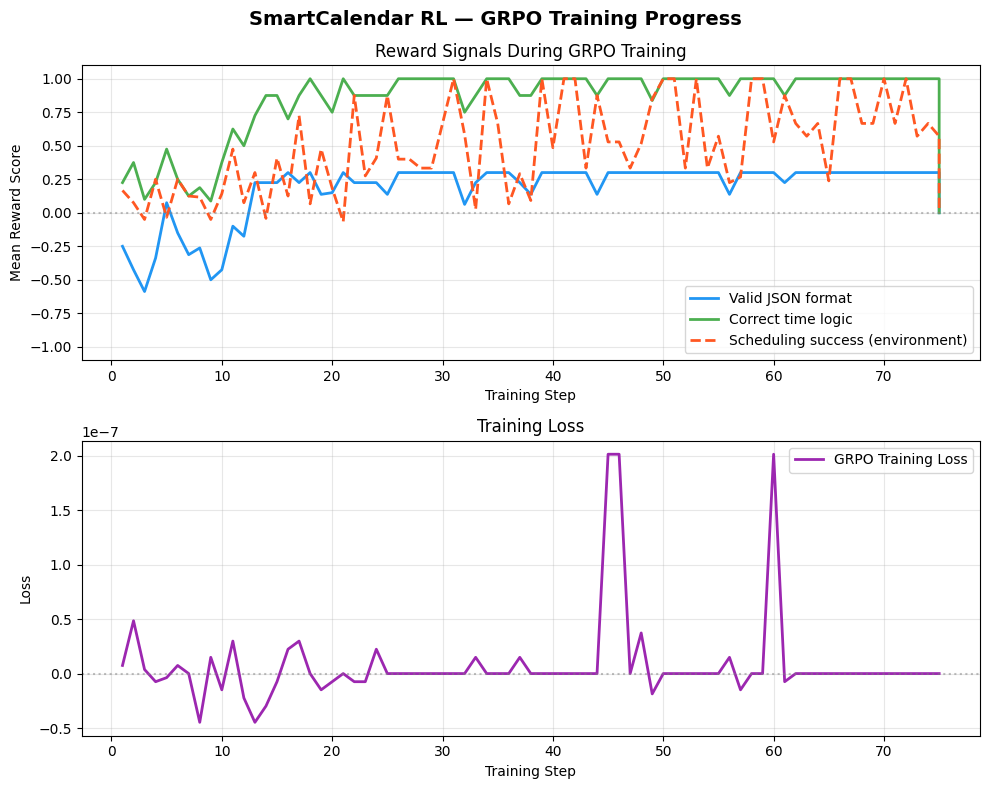

In [50]:
# ── 6. Plot reward curves ─────────────────────────────────────────

import matplotlib.pyplot as plt
steps = training_history["step"]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("SmartCalendar RL — GRPO Training Progress",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ax1.plot(steps, training_history["reward_valid_json"],
         label="Valid JSON format", linewidth=2, color="#2196F3")
ax1.plot(steps, training_history["reward_correct_time"],
         label="Correct time logic", linewidth=2, color="#4CAF50")
ax1.plot(steps, training_history["reward_env_objective"],
         label="Scheduling success (environment)", linewidth=2,
         color="#FF5722", linestyle="--")
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Mean Reward Score")
ax1.set_title("Reward Signals During GRPO Training")
ax1.legend()
ax1.set_ylim(-1.1, 1.1)
ax1.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
ax1.grid(True, alpha=0.3)


ax2 = axes[1]
ax2.plot(steps, training_history["loss"],
         label="GRPO Training Loss", linewidth=2, color="#9C27B0")
ax2.set_xlabel("Training Step")
ax2.set_ylabel("Loss")
ax2.set_title("Training Loss")
ax2.legend()
ax2.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("reward_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Test base llm and the trained llm to see how they behave for booking calendar and collect evidences.

In [45]:
import json
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import AutoTokenizer, AutoModelForCausalLM

from server.smart_calendar_agent_environment import CalendarEnv
from task_definitions import TaskDifficulty
from models import MyCalendarAction, ExpectedAction, PerformedAction, Slot
from inference import build_prompt, parse_time

# ── Helpers ───────────────────────────────────────────────────────

def parse_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group())
    except Exception:
        return None

def model_action(model, tokenizer, state):
    prompt = build_prompt(state)
    full_prompt = (
        "You are a smart calendar scheduling agent. "
        "Return only valid JSON.\n\n"
        f"USER:\n{prompt}\n\nASSISTANT:\n"
    )
    inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    text = tokenizer.decode(
        out[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return parse_json(text), text

def make_action(action_json, fallback_event_id="kickoff"):
    if not action_json:
        action_json = {
            "command": "add_event",
            "event_id": fallback_event_id,
            "day": "monday",
            "start_time": "10:00",
            "end_time": "11:00",
        }
    start_iso = parse_time(action_json.get("start_time", "10:00")).isoformat()
    end_iso   = parse_time(action_json.get("end_time",   "11:00")).isoformat()
    slot      = Slot(start_time=start_iso, end_time=end_iso)
    event_id  = str(action_json.get("event_id", fallback_event_id))
    return MyCalendarAction(
        expected_action=ExpectedAction(
            command=action_json.get("command", "add_event"),
            slot=slot,
            event_id=event_id,
            day=action_json.get("day", "monday"),
        ),
        performed_action=PerformedAction(
            success=True, slot=slot, event_id=event_id
        ),
    )

# ── Max steps per difficulty (match your task_definitions.py) ─────
MAX_STEPS = {
    TaskDifficulty.EASY:   10,
    TaskDifficulty.MEDIUM: 20,
    TaskDifficulty.HARD:   30,
}

# ── Single episode evaluator ──────────────────────────────────────
def run_episode(model, tokenizer, difficulty):
    env = CalendarEnv()
    env.reset(difficulty)
    rewards          = []
    valid_actions    = 0
    invalid_actions  = 0
    rejection_reasons = []

    for _ in range(MAX_STEPS[difficulty]):
        state = env.state
        action_json, raw_text = model_action(model, tokenizer, state)
        obs  = env.step(make_action(action_json))
        meta = obs.metadata or {}

        reward = float(meta.get("reward_objective_progress", 0.0))
        rewards.append(reward)

        if meta.get("action_valid", False):
            valid_actions += 1
        else:
            invalid_actions += 1
            reason = meta.get("rejection_reason")
            if reason:
                rejection_reasons.append(reason)

        if obs.done:
            break

    return {
        "final_score":       env.state.objective_progress,
        "rewards":           rewards,
        "valid_actions":     valid_actions,
        "invalid_actions":   invalid_actions,
        "steps_taken":       len(rewards),
        "rejection_reasons": rejection_reasons,
    }

# ── Multi-episode evaluator (averages across runs) ────────────────
def evaluate_model(model_name, episodes_per_difficulty=3):
    print(f"\nEvaluating: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        torch_dtype="auto",
    )

    results = {}
    for difficulty in [TaskDifficulty.EASY,
                       TaskDifficulty.MEDIUM,
                       TaskDifficulty.HARD]:
        episodes = []
        for ep in range(episodes_per_difficulty):
            print(f"  {difficulty.value} episode {ep+1}/{episodes_per_difficulty}",
                  end="\r")
            episodes.append(run_episode(model, tokenizer, difficulty))

        # Aggregate across episodes
        results[difficulty.value] = {
            "final_score":      np.mean([e["final_score"] for e in episodes]),
            "score_std":        np.std([e["final_score"] for e in episodes]),
            "valid_actions":    np.mean([e["valid_actions"] for e in episodes]),
            "invalid_actions":  np.mean([e["invalid_actions"] for e in episodes]),
            "steps_taken":      np.mean([e["steps_taken"] for e in episodes]),
            # Keep per-step rewards from first episode for progression plot
            "rewards":          episodes[0]["rewards"],
            "all_scores":       [e["final_score"] for e in episodes],
        }
        print(f"  {difficulty.value}: score={results[difficulty.value]['final_score']:.3f}")

    del model  # free GPU memory before loading next model
    torch.cuda.empty_cache()
    return results

# ── Run evaluation ────────────────────────────────────────────────
base_results    = evaluate_model("Qwen/Qwen2.5-0.5B-Instruct",
                                  episodes_per_difficulty=3)
trained_results = evaluate_model("kohantika/smart-calendar-qwen-grpo",
                                  episodes_per_difficulty=3)

with open("eval_results.json", "w") as f:
    json.dump({"base": base_results, "trained": trained_results},
              f, indent=2, default=float)


Evaluating: Qwen/Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  easy: score=0.000


  medium: score=0.333


  hard: score=0.000

Evaluating: kohantika/smart-calendar-qwen-grpo


...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

  easy: score=1.000


  medium: score=0.333


  hard: score=0.143


## Ploting graphs to show how model trained by Smart_Calendar_RL is doing better at calendar booking.

Plot 1 — Bar chart with error bars:
  "Trained model scores higher on all difficulties.
   Error bars show results are consistent across runs."

Plot 2 — Line with shaded improvement:
  "+X.XX" annotations show exact improvement per difficulty.
  Shaded area makes the gap visually obvious in 2 seconds.

Plot 3 — Valid vs Invalid actions:
  "Trained model makes fewer invalid/rejected actions.
   It learned what the environment accepts."
  This is strong evidence of RL working — not just final score.

Plot 4 — Hard task step-by-step:
  "Trained model's reward rises faster within an episode.
   It learns to schedule correctly with fewer wasted steps."

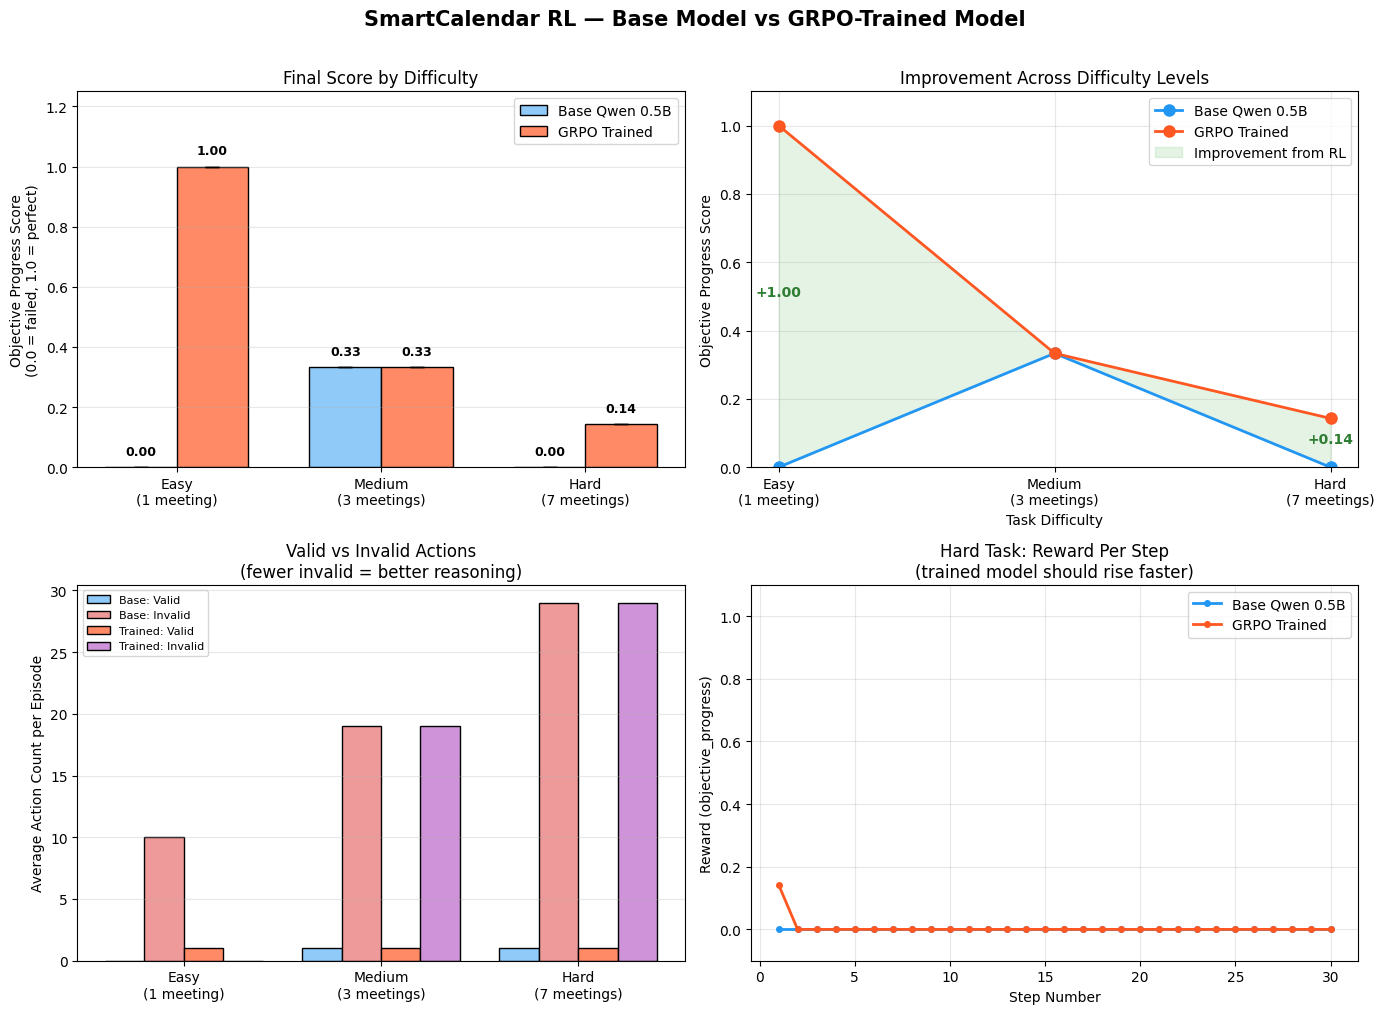

Saved: before_after_comparison.png


In [46]:
labels      = ["Easy\n(1 meeting)", "Medium\n(3 meetings)", "Hard\n(7 meetings)"]
keys        = ["easy", "medium", "hard"]
base_scores = [base_results[k]["final_score"]    for k in keys]
train_scores= [trained_results[k]["final_score"] for k in keys]
base_std    = [base_results[k]["score_std"]      for k in keys]
train_std   = [trained_results[k]["score_std"]   for k in keys]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "SmartCalendar RL — Base Model vs GRPO-Trained Model",
    fontsize=15, fontweight="bold", y=1.01
)

# ── Plot 1: Bar chart with error bars ─────────────────────────────
ax = axes[0][0]
x     = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, base_scores,  width, yerr=base_std,
       label="Base Qwen 0.5B", color="#90CAF9",
       edgecolor="black", capsize=5)
ax.bar(x + width/2, train_scores, width, yerr=train_std,
       label="GRPO Trained",   color="#FF8A65",
       edgecolor="black", capsize=5)
for i, (b, t) in enumerate(zip(base_scores, train_scores)):
    ax.text(i - width/2, b + 0.04, f"{b:.2f}",
            ha="center", fontsize=9, fontweight="bold")
    ax.text(i + width/2, t + 0.04, f"{t:.2f}",
            ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Objective Progress Score\n(0.0 = failed, 1.0 = perfect)")
ax.set_title("Final Score by Difficulty")
ax.set_ylim(0, 1.25)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Improvement line with shaded area ─────────────────────
ax = axes[0][1]
ax.plot(labels, base_scores,  marker="o", linewidth=2,
        markersize=8, label="Base Qwen 0.5B",  color="#2196F3")
ax.plot(labels, train_scores, marker="o", linewidth=2,
        markersize=8, label="GRPO Trained",    color="#FF5722")
ax.fill_between(labels, base_scores, train_scores,
                alpha=0.15, color="#4CAF50",
                label="Improvement from RL")
for i, (b, t) in enumerate(zip(base_scores, train_scores)):
    improvement = t - b
    if improvement > 0:
        ax.annotate(f"+{improvement:.2f}",
                    xy=(i, (b + t) / 2),
                    ha="center", fontsize=10,
                    color="#2E7D32", fontweight="bold")
ax.set_ylabel("Objective Progress Score")
ax.set_xlabel("Task Difficulty")
ax.set_title("Improvement Across Difficulty Levels")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Valid vs Invalid actions ──────────────────────────────
ax = axes[1][0]
x     = np.arange(len(keys))
width = 0.2
base_valid    = [base_results[k]["valid_actions"]   for k in keys]
base_invalid  = [base_results[k]["invalid_actions"] for k in keys]
train_valid   = [trained_results[k]["valid_actions"]   for k in keys]
train_invalid = [trained_results[k]["invalid_actions"] for k in keys]
ax.bar(x - 1.5*width, base_valid,    width, label="Base: Valid",
       color="#90CAF9", edgecolor="black")
ax.bar(x - 0.5*width, base_invalid,  width, label="Base: Invalid",
       color="#EF9A9A", edgecolor="black")
ax.bar(x + 0.5*width, train_valid,   width, label="Trained: Valid",
       color="#FF8A65", edgecolor="black")
ax.bar(x + 1.5*width, train_invalid, width, label="Trained: Invalid",
       color="#CE93D8", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average Action Count per Episode")
ax.set_title("Valid vs Invalid Actions\n(fewer invalid = better reasoning)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── Plot 4: Step-by-step reward progression on Hard task ──────────
ax = axes[1][1]
base_hard_rewards    = base_results["hard"]["rewards"]
trained_hard_rewards = trained_results["hard"]["rewards"]
ax.plot(range(1, len(base_hard_rewards) + 1),
        base_hard_rewards,
        marker="o", markersize=4, linewidth=2,
        label="Base Qwen 0.5B", color="#2196F3")
ax.plot(range(1, len(trained_hard_rewards) + 1),
        trained_hard_rewards,
        marker="o", markersize=4, linewidth=2,
        label="GRPO Trained", color="#FF5722")
ax.set_xlabel("Step Number")
ax.set_ylabel("Reward (objective_progress)")
ax.set_title("Hard Task: Reward Per Step\n(trained model should rise faster)")
ax.set_ylim(-0.1, 1.1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: before_after_comparison.png")